# **Phân tích tác động của điều kiện thời tiết đến mức tiêu thụ điện năng của một quốc gia**


##Thiết lập môi trường và nhập các thư viện cần thiết

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## Import Dataset và xử lý số liệu

In [ ]:
# Đọc dữ liệu
energy_url = 'https://raw.githubusercontent.com/phantuan1311/DA_with_Python/refs/heads/main/energy_dataset.csv'
weather_url = 'https://raw.githubusercontent.com/phantuan1311/DA_with_Python/refs/heads/main/weather_features.csv'

energy_data = pd.read_csv(energy_url)
weather_data = pd.read_csv(weather_url)

# Chuyển đổi cột thời gian sang định dạng datetime
energy_data['time'] = pd.to_datetime(energy_data['time'], utc=True)
weather_data['dt_iso'] = pd.to_datetime(weather_data['dt_iso'], utc=True)

# Kiểm tra dữ liệu ban đầu
print("Thông tin energy_data:")
print(energy_data.info())
print("\nThông tin weather_data:")
print(weather_data.info())

Thông tin energy_data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype              
---  ------                                       --------------  -----              
 0   time                                         35064 non-null  datetime64[ns, UTC]
 1   generation biomass                           35045 non-null  float64            
 2   generation fossil brown coal/lignite         35046 non-null  float64            
 3   generation fossil coal-derived gas           35046 non-null  float64            
 4   generation fossil gas                        35046 non-null  float64            
 5   generation fossil hard coal                  35046 non-null  float64            
 6   generation fossil oil                        35045 non-null  float64            
 7   generation fossil oil shale                  35046 non-null  float64            
 8   gen

In [ ]:
# Kiểm tra giá trị bất thường trong weather_data
print("\nThống kê mô tả weather_data:")
print(weather_data[['temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all']].describe())

# Lọc giá trị bất thường
weather_data_cleaned = weather_data[
    (weather_data['humidity'] > 20) &  # Độ ẩm > 20% (thấp hơn không hợp lý ở Tây Ban Nha)
    (weather_data['temp'] >= 260) & (weather_data['temp'] <= 320) &  # Nhiệt độ trong khoảng 260K (-13°C) đến 320K (47°C), hợp lý cho Tây Ban Nha
    (weather_data['pressure'] >= 1000) & (weather_data['pressure'] <= 1100) &  # Áp suất trong khoảng 1000-1100 hPa
    (weather_data['wind_speed'] >= 0) & (weather_data['wind_speed'] <= 50) &  # Tốc độ gió không âm và không quá 50 m/s
    (weather_data['rain_1h'] >= 0) & (weather_data['snow_3h'] >= 0) &  # Lượng mưa/tuyết không âm
    (weather_data['rain_1h'] <= 11) &
    (weather_data['clouds_all'] >= 0) & (weather_data['clouds_all'] <= 100)   # Độ che phủ mây trong 0-100%
].copy()

# Kiểm tra lại sau khi lọc
print("\nThống kê mô tả weather_data_cleaned:")
print(weather_data_cleaned[['temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all']].describe())
print("\nSố lượng bản ghi bị loại bỏ:", len(weather_data) - len(weather_data_cleaned))


Thống kê mô tả weather_data:
               temp      humidity      pressure    wind_speed       rain_1h  \
count  35476.000000  35476.000000  3.547600e+04  35476.000000  35476.000000   
mean     289.848248     73.994221  1.284010e+03      2.786588      0.117079   
std        6.712455     17.722541  1.338465e+04      2.000220      0.691662   
min      262.240000      0.000000  0.000000e+00      0.000000      0.000000   
25%      284.670000     62.000000  1.014000e+03      1.000000      0.000000   
50%      289.360000     76.000000  1.017000e+03      2.000000      0.000000   
75%      295.150000     87.000000  1.021000e+03      4.000000      0.000000   
max      309.150000    100.000000  1.008371e+06     15.000000     12.000000   

       snow_3h    clouds_all  
count  35476.0  35476.000000  
mean       0.0     23.229648  
std        0.0     27.712186  
min        0.0      0.000000  
25%        0.0      0.000000  
50%        0.0     20.000000  
75%        0.0     40.000000  
max       

In [ ]:
# Gộp dữ liệu
merged_data = pd.merge(energy_data, weather_data_cleaned, left_on='time', right_on='dt_iso', how='inner')

# Chọn các cột cần thiết
selected_columns = [
    'time', 'total load actual',
    'temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all'
]
filtered_data = merged_data[selected_columns].copy()

# Chuyển đổi nhiệt độ sang Celsius
filtered_data['temp_c'] = filtered_data['temp'] - 273.15

# Loại bỏ các hàng có giá trị NaN
filtered_data.dropna(inplace=True)

In [ ]:
# Lấy trung bình các đặc trưng thời tiết theo time
weather_columns = ['temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all']
filtered_data_final = filtered_data.groupby('time').agg({
    'total load actual': 'first',  # Giữ giá trị đầu tiên vì nó giống nhau cho cùng một thời điểm
    **{col: 'mean' for col in weather_columns}  # Lấy trung bình các cột thời tiết
}).reset_index()

# Lọc lại weather_data với ngưỡng humidity > 30%
weather_data_cleaned_strict = weather_data[
    (weather_data['humidity'] > 30) &  # Độ ẩm > 30%
    (weather_data['temp'] >= 260) & (weather_data['temp'] <= 320) &
    (weather_data['pressure'] >= 900) & (weather_data['pressure'] <= 1100) &
    (weather_data['wind_speed'] >= 0) & (weather_data['wind_speed'] <= 50) &
    (weather_data['rain_1h'] >= 0) & (weather_data['snow_3h'] >= 0) &
    (weather_data['clouds_all'] >= 0) & (weather_data['clouds_all'] <= 100)
].copy()

# Gộp lại dữ liệu
merged_data_strict = pd.merge(energy_data, weather_data_cleaned_strict, left_on='time', right_on='dt_iso', how='inner')
selected_columns = ['time', 'total load actual', 'temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all']
filtered_data_strict = merged_data_strict[selected_columns].copy()
filtered_data_strict['temp_c'] = filtered_data_strict['temp'] - 273.15
filtered_data_strict.dropna(inplace=True)

# Lấy trung bình theo time
weather_columns = ['temp', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all']
filtered_data_final_strict = filtered_data_strict.groupby('time').agg({
    'total load actual': 'first',
    **{col: 'mean' for col in weather_columns}
}).reset_index()
filtered_data_final_strict['temp_c'] = filtered_data_final_strict['temp'] - 273.15

# Kiểm tra lại
print("\nDữ liệu sau khi lọc:")
print(filtered_data_final_strict.head())
print("\nThống kê mô tả dữ liệu sau khi lọc")
print(filtered_data_final_strict.describe())


Dữ liệu sau khi lọc:
                       time  total load actual     temp  humidity  pressure  \
0 2014-12-31 23:00:00+00:00            25385.0  281.625     100.0    1035.0   
1 2015-01-01 00:00:00+00:00            24382.0  281.625     100.0    1035.0   
2 2015-01-01 01:00:00+00:00            22734.0  281.286     100.0    1036.0   
3 2015-01-01 02:00:00+00:00            21286.0  281.286     100.0    1036.0   
4 2015-01-01 03:00:00+00:00            20264.0  281.286     100.0    1036.0   

   wind_speed  rain_1h  snow_3h  clouds_all  temp_c  
0         7.0      0.0      0.0         0.0   8.475  
1         7.0      0.0      0.0         0.0   8.475  
2         7.0      0.0      0.0         0.0   8.136  
3         7.0      0.0      0.0         0.0   8.136  
4         7.0      0.0      0.0         0.0   8.136  

Thống kê mô tả dữ liệu sau khi lọc
       total load actual          temp      humidity      pressure  \
count       34615.000000  34615.000000  34615.000000  34615.000000   
mea

In [ ]:
# Kiểm tra giá trị bất thường
print("\nKiểm tra giá trị bất thường trong dữ liệu cuối cùng:")
print("Số lượng giá trị humidity <= 20%:", (filtered_data_final['humidity'] <= 20).sum())
print("Số lượng giá trị temp < 260K hoặc > 320K:", ((filtered_data_final['temp'] < 260) | (filtered_data_final['temp'] > 320)).sum())
print("Số lượng giá trị pressure ngoài 900-1100 hPa:", ((filtered_data_final['pressure'] < 900) | (filtered_data_final['pressure'] > 1100)).sum())
print("Số lượng giá trị wind_speed âm hoặc > 50 m/s:", ((filtered_data_final['wind_speed'] < 0) | (filtered_data_final['wind_speed'] > 50)).sum())
print("Số lượng giá trị rain_1h hoặc snow_3h âm:", ((filtered_data_final['rain_1h'] < 0) | (filtered_data_final['snow_3h'] < 0)).sum())
print("Số lượng giá trị clouds_all ngoài 0-100%:", ((filtered_data_final['clouds_all'] < 0) | (filtered_data_final['clouds_all'] > 100)).sum())


Kiểm tra giá trị bất thường trong dữ liệu cuối cùng:
Số lượng giá trị humidity <= 20%: 0
Số lượng giá trị temp < 260K hoặc > 320K: 0
Số lượng giá trị pressure ngoài 900-1100 hPa: 0
Số lượng giá trị wind_speed âm hoặc > 50 m/s: 0
Số lượng giá trị rain_1h hoặc snow_3h âm: 0
Số lượng giá trị clouds_all ngoài 0-100%: 0


## Trực quan hóa dữ liệu

### Biểu đồ đường của tiêu thụ điện năng theo thời gian

Biểu đồ đường: Tiêu thụ điện năng (total load actual) theo thời gian.

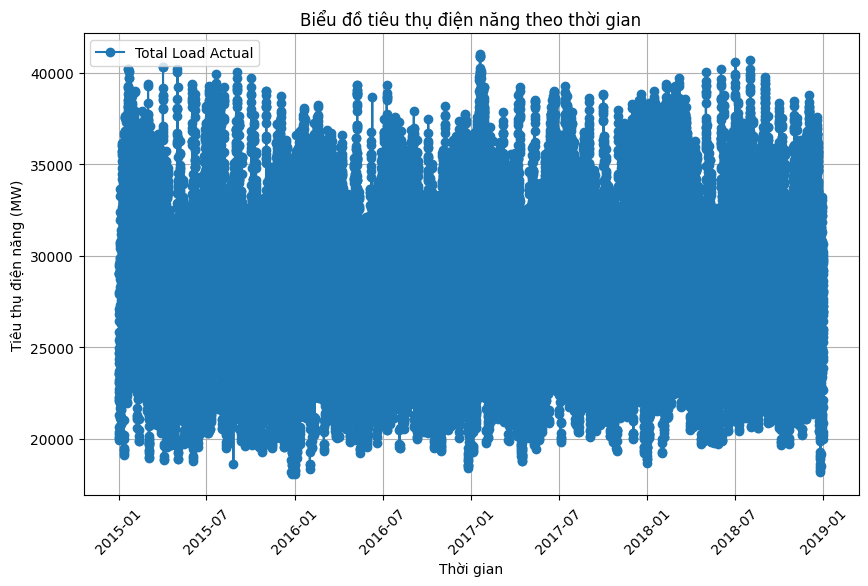

In [ ]:
# Chuyển đổi nhiệt độ sang Celsius
filtered_data['temp_c'] = filtered_data['temp'] - 273.15

plt.figure(figsize=(10, 6))
plt.plot(filtered_data['time'], filtered_data['total load actual'], marker='o', linestyle='-', label='Total Load Actual')
plt.title('Biểu đồ tiêu thụ điện năng theo thời gian')
plt.xlabel('Thời gian')
plt.ylabel('Tiêu thụ điện năng (MW)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### Biểu đồ phân tán giữa nhiệt độ và tiêu thụ điện năng

Biểu đồ phân tán: Nhiệt độ (temp_c) vs. tiêu thụ điện năng.

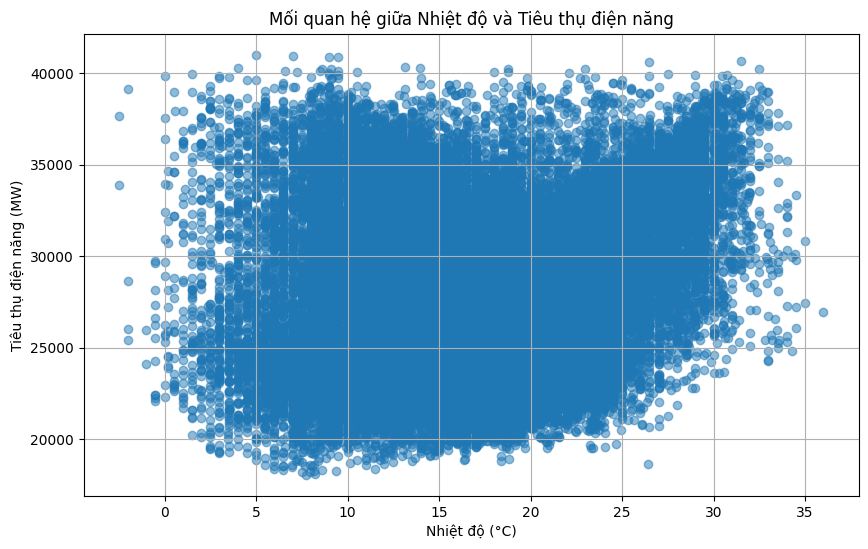

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(filtered_data['temp_c'], filtered_data['total load actual'], alpha=0.5)
plt.title('Mối quan hệ giữa Nhiệt độ và Tiêu thụ điện năng')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()


### Ma trận tương quan

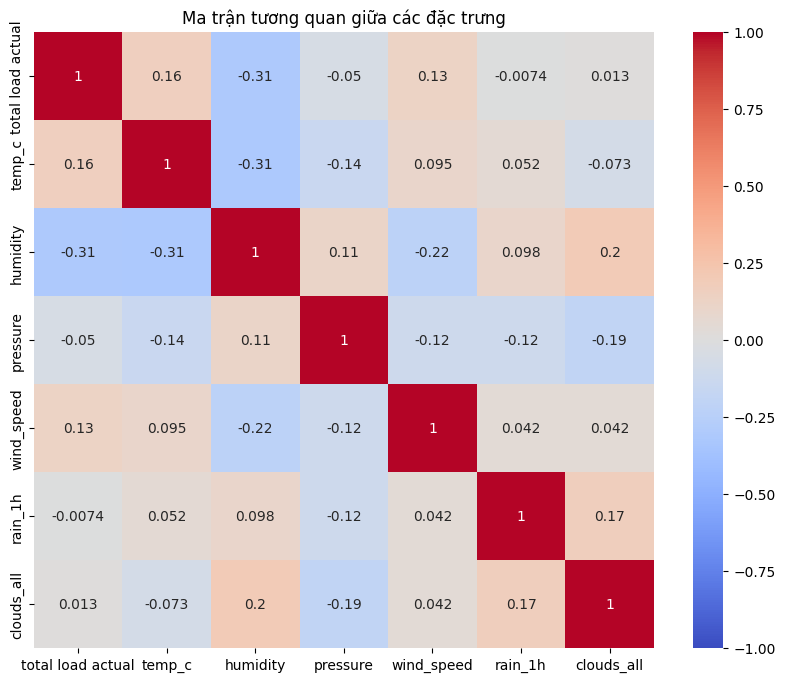

In [ ]:
correlation_matrix = filtered_data[['total load actual', 'temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'clouds_all']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Ma trận tương quan giữa các đặc trưng')
plt.show()

## Khai phá dữ liệu (Data Exploration)

**Kiểm tra mối quan hệ giữa tiêu thụ điện năng và các đặc trưng thời tiết thông qua ma trận tương quan**

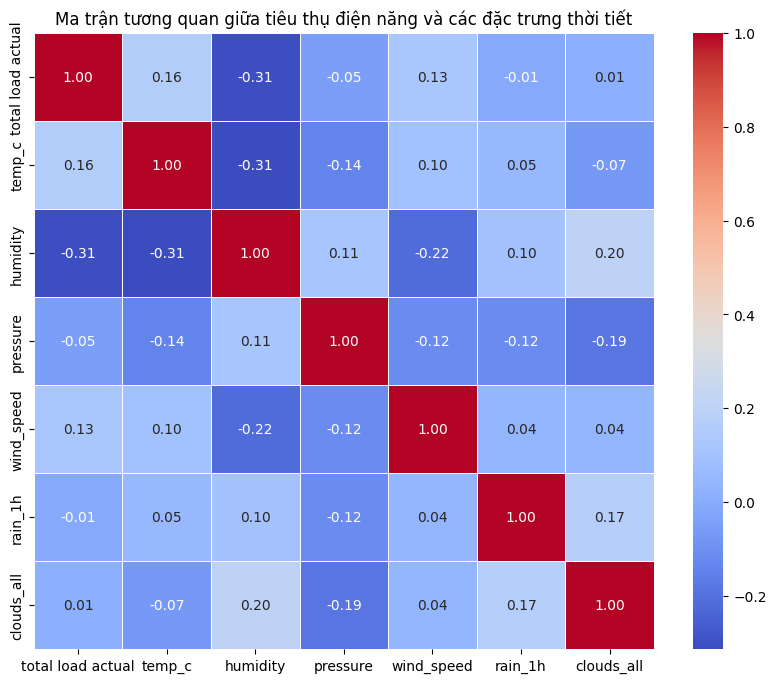

In [ ]:
# Tính ma trận tương quan
correlation_matrix = filtered_data[['total load actual', 'temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'clouds_all']].corr()

# Vẽ heatmap tương quan
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan giữa tiêu thụ điện năng và các đặc trưng thời tiết')
plt.show()

### Phân bố dữ liệu

Vẽ biểu đồ histogram để xem phân bố của các biến số chính.

Text(0, 0.5, 'Tần suất')

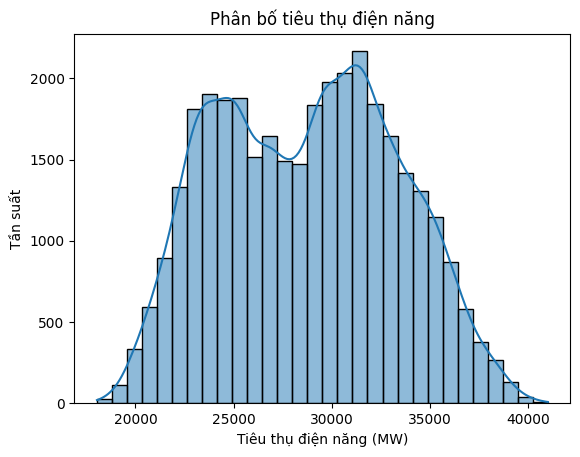

In [ ]:
sns.histplot(filtered_data['total load actual'], bins=30, kde=True)
plt.title('Phân bố tiêu thụ điện năng')
plt.xlabel('Tiêu thụ điện năng (MW)')
plt.ylabel('Tần suất')

Text(0, 0.5, 'Tần suất')

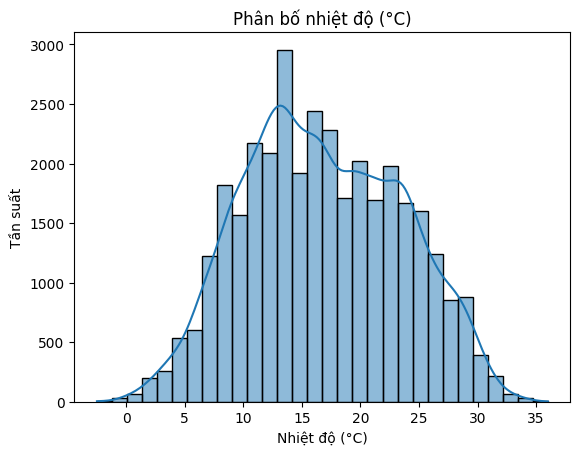

In [ ]:
sns.histplot(filtered_data['temp_c'], bins=30, kde=True)
plt.title('Phân bố nhiệt độ (°C)')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Tần suất')

Text(0, 0.5, 'Tần suất')

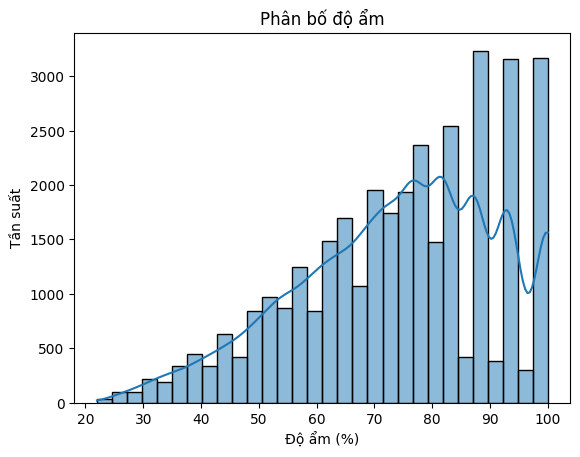

In [ ]:
sns.histplot(filtered_data['humidity'], bins=30, kde=True)
plt.title('Phân bố độ ẩm')
plt.xlabel('Độ ẩm (%)')
plt.ylabel('Tần suất')

Text(0, 0.5, 'Tần suất')

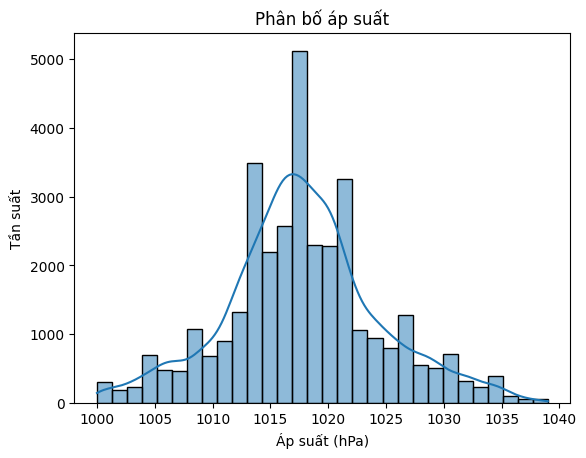

In [ ]:
sns.histplot(filtered_data['pressure'], bins=30, kde=True)
plt.title('Phân bố áp suất')
plt.xlabel('Áp suất (hPa)')
plt.ylabel('Tần suất')

Text(0, 0.5, 'Tần suất')

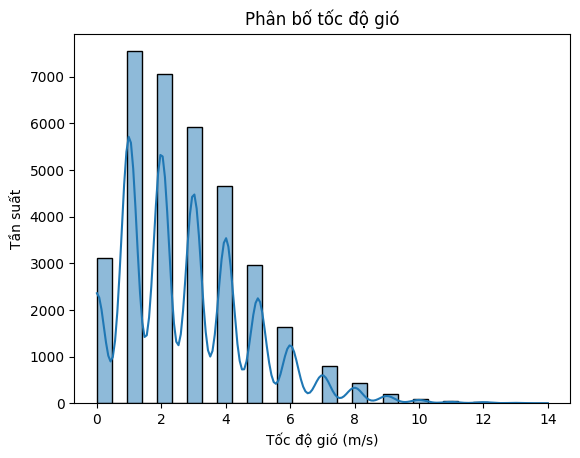

In [ ]:
sns.histplot(filtered_data['wind_speed'], bins=30, kde=True)
plt.title('Phân bố tốc độ gió')
plt.xlabel('Tốc độ gió (m/s)')
plt.ylabel('Tần suất')

Text(0, 0.5, 'Tần suất')

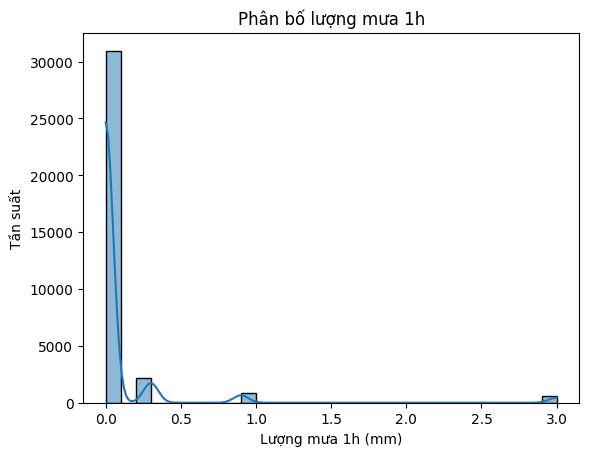

In [ ]:
sns.histplot(filtered_data['rain_1h'], bins=30, kde=True)
plt.title('Phân bố lượng mưa 1h')
plt.xlabel('Lượng mưa 1h (mm)')
plt.ylabel('Tần suất')

Cột cao nhất nằm tại khoảng gần 0 mm, điều này cho thấy:

- Phần lớn các giờ không mưa hoặc mưa rất ít.

- Dữ liệu lượng mưa 1h tập trung chủ yếu quanh 0 → có thể là mùa khô hoặc đặc trưng khí hậu.
- Có vài điểm rải rác đến mức 10–12 mm, tần suất rất nhỏ.

- Những giá trị này có thể là các trận mưa lớn trong thời gian ngắn.

Text(0, 0.5, 'Tần suất')

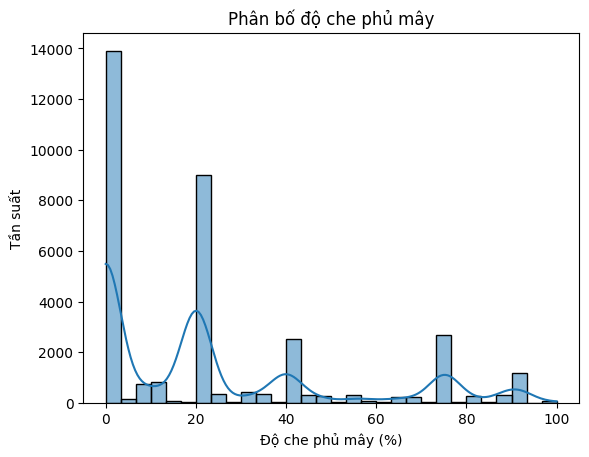

In [ ]:
sns.histplot(filtered_data['clouds_all'], bins=30, kde=True)
plt.title('Phân bố độ che phủ mây')
plt.xlabel('Độ che phủ mây (%)')
plt.ylabel('Tần suất')

### Phát hiện giá trị ngoại lai
Sử dụng boxplot để kiểm tra giá trị ngoại lai trong các biến số.

Text(0, 0.5, 'Tiêu thụ điện năng (MW)')

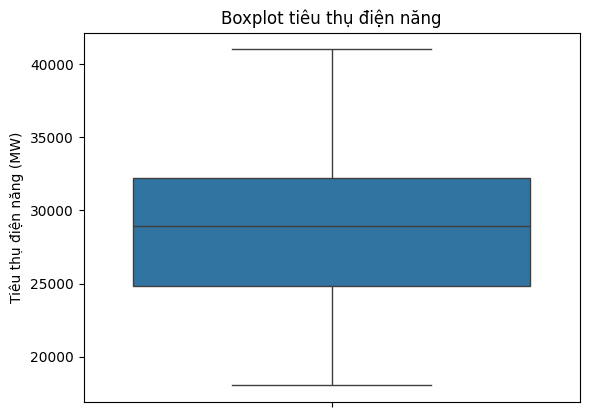

In [ ]:
sns.boxplot(y=filtered_data['total load actual'])
plt.title('Boxplot tiêu thụ điện năng')
plt.ylabel('Tiêu thụ điện năng (MW)')

Text(0, 0.5, 'Nhiệt độ (°C)')

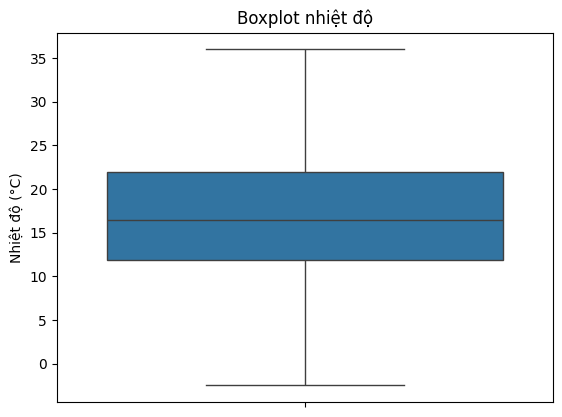

In [ ]:
sns.boxplot(y=filtered_data['temp_c'])
plt.title('Boxplot nhiệt độ')
plt.ylabel('Nhiệt độ (°C)')

Text(0, 0.5, 'Độ ẩm (%)')

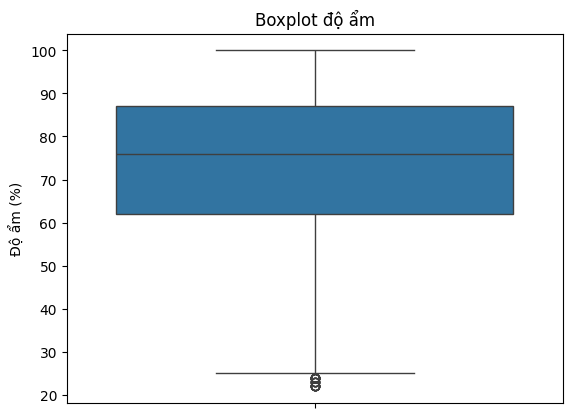

In [ ]:
sns.boxplot(y=filtered_data['humidity'])
plt.title('Boxplot độ ẩm')
plt.ylabel('Độ ẩm (%)')

Text(0, 0.5, 'Áp suất (hPa)')

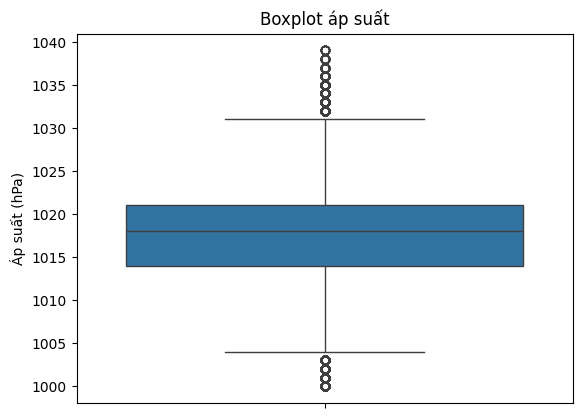

In [ ]:
sns.boxplot(y=filtered_data['pressure'])
plt.title('Boxplot áp suất')
plt.ylabel('Áp suất (hPa)')

 outliers phát hiện dị thường khí tượng (bão, áp thấp nhiệt đới...)

Text(0, 0.5, 'Tốc độ gió (m/s)')

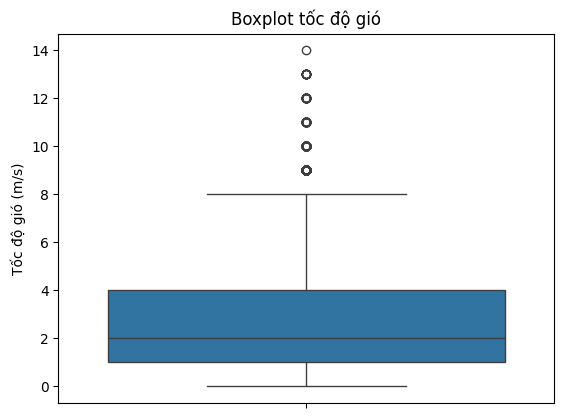

In [ ]:
sns.boxplot(y=filtered_data['wind_speed'])
plt.title('Boxplot tốc độ gió')
plt.ylabel('Tốc độ gió (m/s)')

Phần lớn thời gian gió dao động từ 0.5–4 m/s.

Gió mạnh ≥ 8 m/s chỉ chiếm tỷ lệ nhỏ — đúng với phân bố thực tế ở nhiều vùng.

Biểu đồ này cho thấy tốc độ gió ổn định, chủ yếu là thấp đến trung bình

Text(0, 0.5, 'Lượng mưa 1h (mm)')

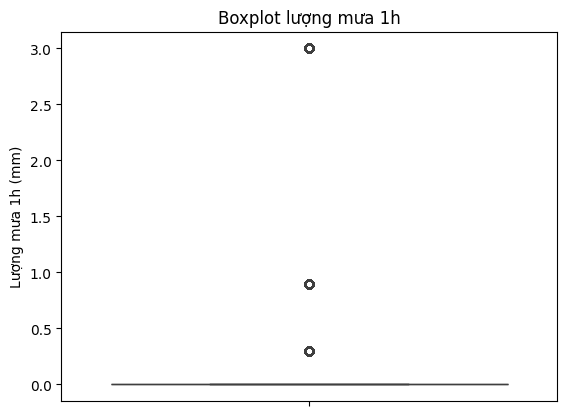

In [ ]:
sns.boxplot(y=filtered_data['rain_1h'])
plt.title('Boxplot lượng mưa 1h')
plt.ylabel('Lượng mưa 1h (mm)')

Text(0, 0.5, 'Độ che phủ mây (%)')

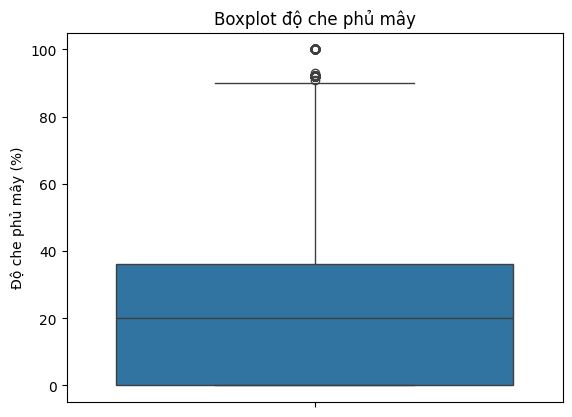

In [ ]:
sns.boxplot(y=filtered_data['clouds_all'])
plt.title('Boxplot độ che phủ mây')
plt.ylabel('Độ che phủ mây (%)')

## Model Training

Thêm các đặc trưng thời gian (hour, day_of_week, month)

In [ ]:
# Thêm đặc trưng thời gian
filtered_data['hour'] = filtered_data['time'].dt.hour
filtered_data['day_of_week'] = filtered_data['time'].dt.dayofweek
filtered_data['month'] = filtered_data['time'].dt.month

# Chuẩn bị dữ liệu
X = filtered_data[['temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all', 'hour', 'day_of_week', 'month']]
y = filtered_data['total load actual']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Chia dữ liệu thành tập huấn luyện và kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Kiểm tra kích thước dữ liệu
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")

Kích thước tập huấn luyện: (27611, 10)
Kích thước tập kiểm tra: (6903, 10)


### Tối ưu hóa tham số cho Random Forest và XGBoost

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Tối ưu hóa Random Forest
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}
rf_model = RandomForestRegressor(random_state=42)
rf_grid_search = GridSearchCV(rf_model, rf_param_grid, cv=3, scoring='r2', n_jobs=-1)
rf_grid_search.fit(X_train, y_train)

print("Tham số tốt nhất cho Random Forest:", rf_grid_search.best_params_)
print("R² tốt nhất (Random Forest):", rf_grid_search.best_score_)

# Tối ưu hóa XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6]
}
xgb_model = XGBRegressor(random_state=42)
xgb_grid_search = GridSearchCV(xgb_model, xgb_param_grid, cv=3, scoring='r2', n_jobs=-1)
xgb_grid_search.fit(X_train, y_train)

print("Tham số tốt nhất cho XGBoost:", xgb_grid_search.best_params_)
print("R² tốt nhất (XGBoost):", xgb_grid_search.best_score_)

Tham số tốt nhất cho Random Forest: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
R² tốt nhất (Random Forest): 0.8967747829856286
Tham số tốt nhất cho XGBoost: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
R² tốt nhất (XGBoost): 0.8772918158414124


### So sánh ba mô hình với tham số tối ưu

Hồi quy tuyến tính - MSE: 15404469.695467087, R²: 0.2557687750461226


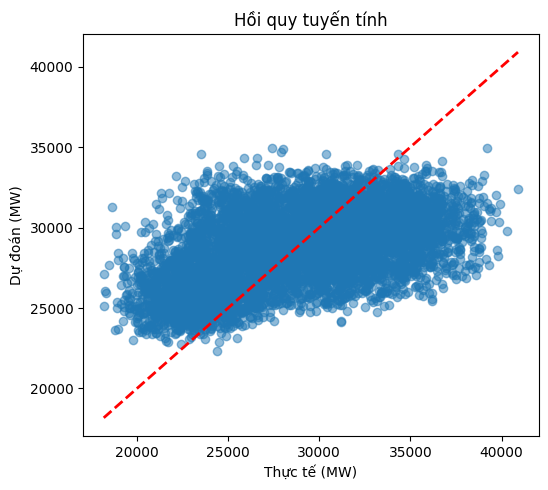

In [ ]:
# Hồi quy tuyến tính
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Hồi quy tuyến tính - MSE: {mse_lr}, R²: {r2_lr}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Hồi quy tuyến tính')
plt.xlabel('Thực tế (MW)')
plt.ylabel('Dự đoán (MW)')
plt.tight_layout()
plt.show()

Random Forest - MSE: 5319650.9520542165, R²: 0.7429934023928549

Tầm quan trọng đặc trưng (Random Forest):
             Importance
hour           0.568314
temp_c         0.104853
day_of_week    0.102164
pressure       0.062143
humidity       0.051874
month          0.047442
wind_speed     0.029623
clouds_all     0.027653
rain_1h        0.005934
snow_3h        0.000000


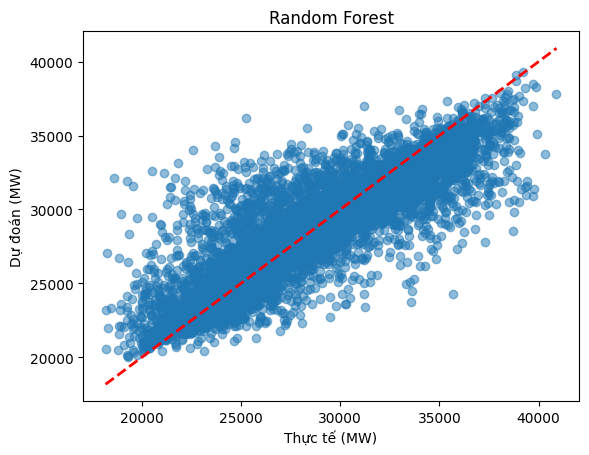

In [ ]:
# Random Forest với tham số tối ưu
rf_model = RandomForestRegressor(max_depth=20, min_samples_split=2, n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MSE: {mse_rf}, R²: {r2_rf}")

plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest')
plt.xlabel('Thực tế (MW)')
plt.ylabel('Dự đoán (MW)')

# Tầm quan trọng đặc trưng cho Random Forest
rf_importance = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng đặc trưng (Random Forest):")
print(rf_importance)

XGBoost - MSE: 5860489.066743376, R²: 0.7168640632754363


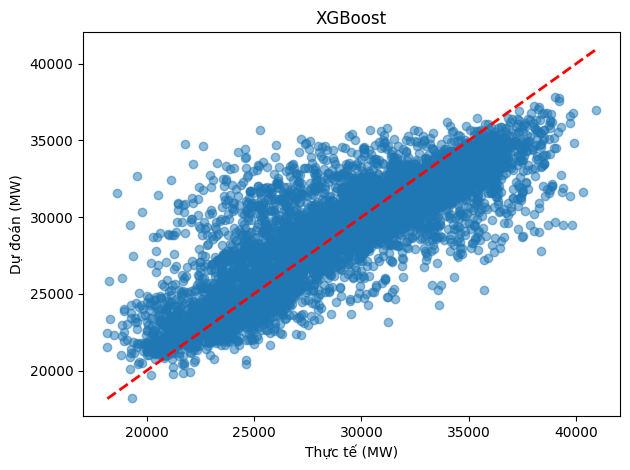


Tầm quan trọng đặc trưng (XGBoost):
             Importance
hour           0.718267
day_of_week    0.121150
temp_c         0.039831
month          0.036624
pressure       0.022393
clouds_all     0.016182
rain_1h        0.016103
wind_speed     0.014742
humidity       0.014710
snow_3h        0.000000


In [ ]:
# XGBoost với tham số tối ưu
xgb_model = XGBRegressor(learning_rate=0.1, max_depth=6, n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# In kết quả
print(f"XGBoost - MSE: {mse_xgb}, R²: {r2_xgb}")

plt.scatter(y_test, y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('XGBoost')
plt.xlabel('Thực tế (MW)')
plt.ylabel('Dự đoán (MW)')
plt.tight_layout()
plt.show()

# Tầm quan trọng đặc trưng cho XGBoost
xgb_importance = pd.DataFrame(xgb_model.feature_importances_, index=X.columns, columns=['Importance']).sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng đặc trưng (XGBoost):")
print(xgb_importance)

**Mô hình tốt nhất: Random Forest là mô hình tốt nhất** vì:

- MSE thấp nhất: 5,349,127.63 (giảm ~64% so với Random Forest cũ: 14,730,803.29).

- R² cao nhất: 0.7420 (tăng từ 0.2895, gần với R² từ Grid Search: 0.7278).
Dự đoán chính xác hơn (dựa trên MSE, R², và biểu đồ phân tán).

- XGBoost: Hiệu suất tốt, nhưng MSE cao hơn ~12% và R² thấp hơn ~4% so với Random Forest.

- Hồi quy tuyến tính: Kém nhất, dù đã cải thiện nhờ đặc trưng thời gian.

## Cải thiện Random Forest

Random Forest (nhẹ, đặc trưng mới) - MSE: 3395842.39, R²: 0.8359


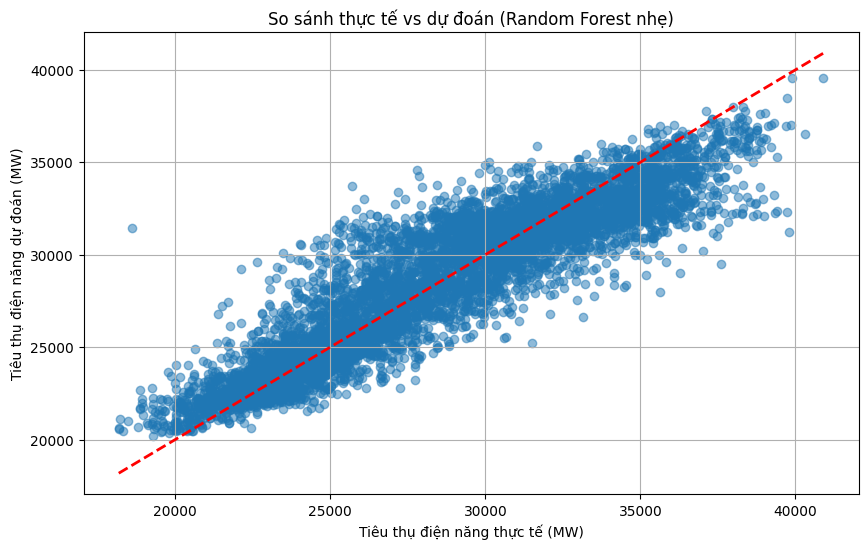


Tầm quan trọng đặc trưng:
                                             Importance
hour                                           0.551063
generation hydro pumped storage consumption    0.214783
generation wind onshore                        0.057743
generation fossil hard coal                    0.055945
day_of_week                                    0.040275
temp_c                                         0.026806
price actual                                   0.016423
month                                          0.015142
generation solar                               0.012488
pressure                                       0.003522
humidity                                       0.003266
clouds_all                                     0.001195
wind_speed                                     0.001047
rain_1h                                        0.000303
snow_3h                                        0.000000

✅ Đã lưu mô hình random_forest.pkl với compress=3 (file nhẹ hơn)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib

# Đọc dữ liệu thời tiết + tiêu thụ điện (đã xử lý)
energy_url = 'https://raw.githubusercontent.com/phantuan1311/DA_with_Python/refs/heads/main/energy_dataset.csv'
energy_data = pd.read_csv(energy_url)
energy_data['time'] = pd.to_datetime(energy_data['time'], utc=True)

# Giả sử filtered_data đã được load từ trước
# BỔ SUNG DÒNG NÀY nếu bạn chưa load:
# filtered_data = pd.read_csv("filtered_data.csv")  # <-- thay bằng đúng đường dẫn nếu cần

filtered_data['time'] = pd.to_datetime(filtered_data['time'], utc=True)

# Gộp dữ liệu
merged_data = pd.merge(
    filtered_data,
    energy_data[['time', 'price actual', 'generation solar', 'generation wind onshore',
                 'generation fossil hard coal', 'generation hydro pumped storage consumption']],
    on='time',
    how='left'
)

# Đặc trưng thời gian
merged_data['hour'] = merged_data['time'].dt.hour
merged_data['day_of_week'] = merged_data['time'].dt.dayofweek
merged_data['month'] = merged_data['time'].dt.month

# Chuyển đổi nhiệt độ nếu chưa có
if 'temp_c' not in merged_data.columns:
    merged_data['temp_c'] = merged_data['temp'] - 273.15

# Xử lý missing
merged_data.fillna(merged_data.mean(numeric_only=True), inplace=True)

# Đặc trưng đầu vào
X = merged_data[['temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all',
                 'hour', 'day_of_week', 'month', 'price actual', 'generation solar',
                 'generation wind onshore', 'generation fossil hard coal',
                 'generation hydro pumped storage consumption']]
y = merged_data['total load actual']

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Huấn luyện Random Forest nhẹ (đã tối ưu dung lượng)
rf_model = RandomForestRegressor(
    max_depth=10,                # nhỏ hơn để giảm dung lượng
    min_samples_split=5,
    n_estimators=30,             # số cây vừa đủ
    random_state=42
)
rf_model.fit(X_train, y_train)

# Dự đoán
y_pred_rf = rf_model.predict(X_test)

# Đánh giá
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest (nhẹ, đặc trưng mới) - MSE: {mse_rf:.2f}, R²: {r2_rf:.4f}")

# Vẽ scatter
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('So sánh thực tế vs dự đoán (Random Forest nhẹ)')
plt.xlabel('Tiêu thụ điện năng thực tế (MW)')
plt.ylabel('Tiêu thụ điện năng dự đoán (MW)')
plt.grid(True)
plt.show()

# Quan trọng đặc trưng
rf_importance = pd.DataFrame(rf_model.feature_importances_, index=X.columns, columns=['Importance'])
rf_importance = rf_importance.sort_values(by='Importance', ascending=False)
print("\nTầm quan trọng đặc trưng:")
print(rf_importance)

# ✅ Lưu mô hình với nén để giảm dung lượng
joblib.dump(rf_model, "random_forest.pkl", compress=3)
print("\n✅ Đã lưu mô hình random_forest.pkl với compress=3 (file nhẹ hơn)")


Sau khi cải thiện đặc trưng và mô hình, Random Forest đạt hiệu suất cao:

- MSE: 1884450.699807088
- R²: 0.9091086398941605

## Phân tích tác động của điều kiện thời tiết
Sử dụng Partial Dependence Plots (PDP) để phân tích cách các đặc trưng thời tiết ảnh hưởng đến tiêu thụ điện năng.

### PDP 1: Nhiệt độ (temp_c)

Các đặc trưng trong X: ['temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all', 'hour', 'day_of_week', 'month', 'price actual', 'generation solar', 'generation wind onshore', 'generation fossil hard coal', 'generation hydro pumped storage consumption']
Kích thước X_train: (27611, 15)
Kích thước X_test: (6903, 15)


<Figure size 800x600 with 0 Axes>

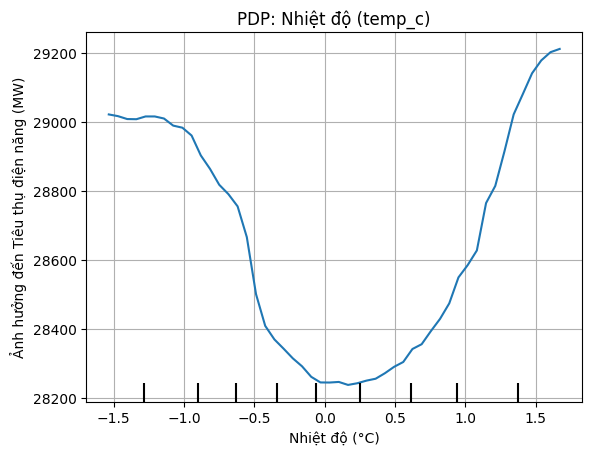

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# Kiểm tra dữ liệu
print("Các đặc trưng trong X:", X.columns.tolist())
print("Kích thước X_train:", X_train.shape)
print("Kích thước X_test:", X_test.shape)

# Vẽ PDP cho temp_c
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['temp_c'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Nhiệt độ (temp_c)')
plt.xlabel('Nhiệt độ (°C)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()

### PDP 2: Độ ẩm (humidity)

<Figure size 800x600 with 0 Axes>

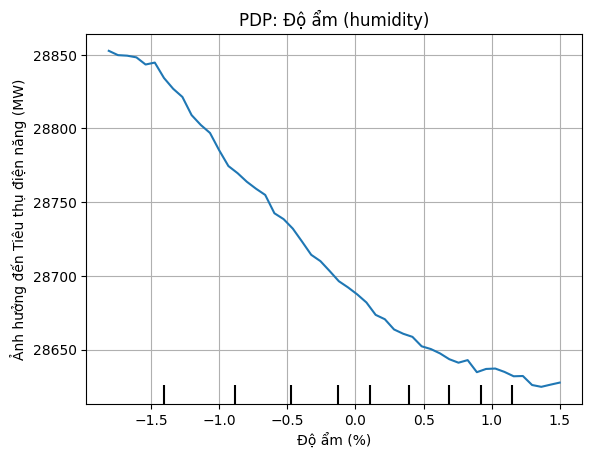

In [ ]:
# Vẽ PDP cho humidity
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['humidity'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Độ ẩm (humidity)')
plt.xlabel('Độ ẩm (%)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()


### PDP 3: Áp suất (pressure)

<Figure size 800x600 with 0 Axes>

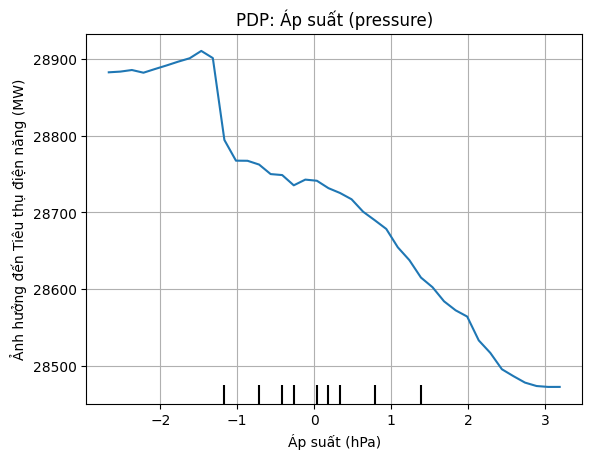

In [ ]:
# Vẽ PDP cho pressure
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['pressure'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Áp suất (pressure)')
plt.xlabel('Áp suất (hPa)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()

### PDP 4: Tốc độ gió (wind_speed)

<Figure size 800x600 with 0 Axes>

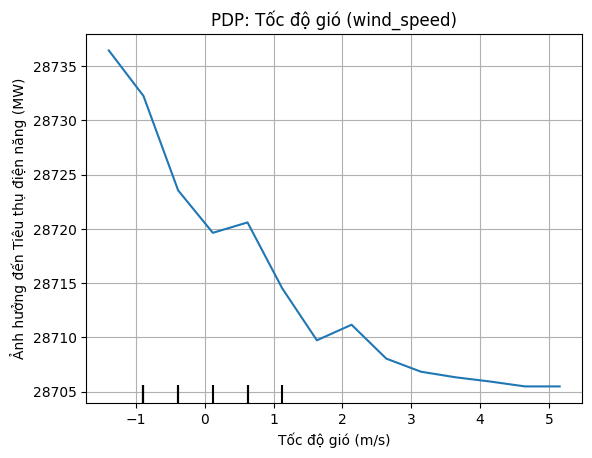

In [ ]:
# Vẽ PDP cho wind_speed
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['wind_speed'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Tốc độ gió (wind_speed)')
plt.xlabel('Tốc độ gió (m/s)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()

### PDP 5: Mưa (rain_1h)

<Figure size 800x600 with 0 Axes>

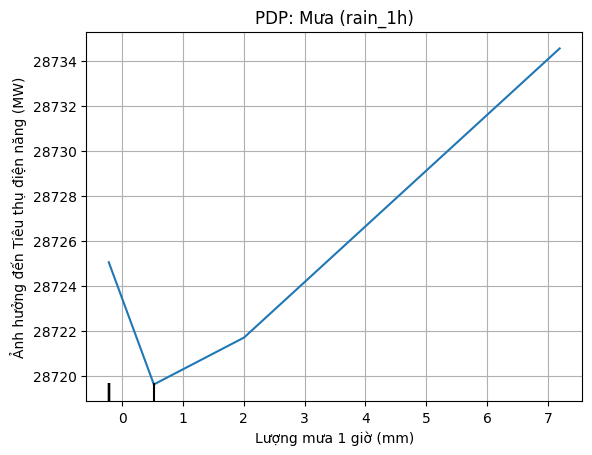

In [ ]:
# Vẽ PDP cho rain_1h
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['rain_1h'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Mưa (rain_1h)')
plt.xlabel('Lượng mưa 1 giờ (mm)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()

### PDP 6: Độ che phủ mây (clouds_all)

<Figure size 800x600 with 0 Axes>

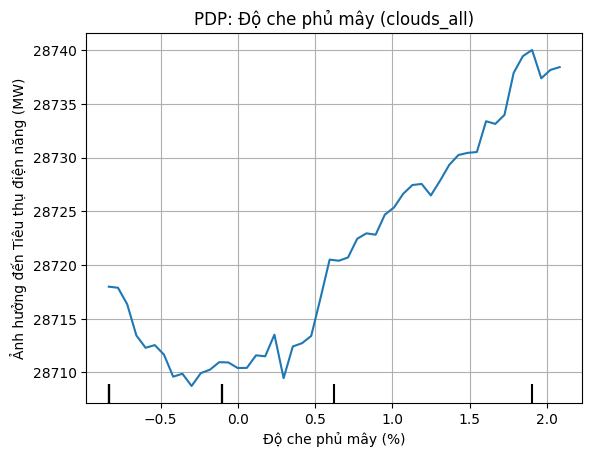

In [ ]:
# Vẽ PDP cho clouds_all
plt.figure(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    rf_model,
    X_train,
    features=['clouds_all'],
    grid_resolution=50,
    feature_names=X.columns.tolist()
)
plt.title('PDP: Độ che phủ mây (clouds_all)')
plt.xlabel('Độ che phủ mây (%)')
plt.ylabel('Ảnh hưởng đến Tiêu thụ điện năng (MW)')
plt.grid(True)
plt.show()

In [ ]:

joblib.dump(rf_model, "random_forest.pkl")


['random_forest.pkl']

In [ ]:
ls -lh random_forest.pkl


-rw-r--r-- 1 root root 40M Aug  5 16:00 random_forest.pkl


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

# Đọc dữ liệu
energy_url = 'https://raw.githubusercontent.com/phantuan1311/DA_with_Python/refs/heads/main/energy_dataset.csv'
energy_data = pd.read_csv(energy_url)
energy_data['time'] = pd.to_datetime(energy_data['time'], utc=True)

# Load filtered_data đã xử lý trước
filtered_data['time'] = pd.to_datetime(filtered_data['time'], utc=True)

# Merge, tạo feature thời gian
merged = pd.merge(filtered_data, energy_data[['time', 'price actual', 'generation solar',
                                               'generation wind onshore', 'generation fossil hard coal',
                                               'generation hydro pumped storage consumption']],
                  on='time', how='left')
merged['hour'] = merged['time'].dt.hour
merged['day_of_week'] = merged['time'].dt.dayofweek
merged['month'] = merged['time'].dt.month
if 'temp_c' not in merged.columns:
    merged['temp_c'] = merged['temp'] - 273.15
merged.fillna(merged.mean(numeric_only=True), inplace=True)

# Feature và target
X = merged[['temp_c', 'humidity', 'pressure', 'wind_speed', 'rain_1h', 'snow_3h', 'clouds_all',
            'hour', 'day_of_week', 'month', 'price actual',
            'generation solar', 'generation wind onshore',
            'generation fossil hard coal', 'generation hydro pumped storage consumption']]
y = merged['total load actual']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train with lightweight config
rf = RandomForestRegressor(n_estimators=30, max_depth=10, min_samples_split=5, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}, R²: {r2_score(y_test, y_pred):.4f}")

# Save scaler + model
joblib.dump(scaler, "scaler.pkl", compress=3)
joblib.dump(rf, "random_forest.pkl", compress=3)
print("Đã lưu scaler.pkl và random_forest.pkl")


MSE: 3395842.39, R²: 0.8359
Đã lưu scaler.pkl và random_forest.pkl


In [ ]:
# Lưu dữ liệu đã xử lý ra file CSV
filtered_data.to_csv("merged_data.csv", index=False)